# MSc Project: Investigating Takeaway Density, Deprivation and Obesity in London

**Student:** Zisan Ahmed  
**Student ID:** 24162855  
**Module:** 7COM1075 - Data Science and Analytics Masters Project  
**Date:** July 2026

---

## Notebook Overview

This notebook performs the complete data analysis for the MSc project. The project investigates whether areas in London with more takeaway food outlets have higher rates of adult obesity, and whether deprivation (poverty) is the real reason behind this relationship.

### Project Structure

1. **Data Loading** - Load all required datasets
2. **Data Cleaning** - Filter for London and takeaways
3. **Data Integration** - Map postcodes to LSOAs and boroughs
4. **Feature Engineering** - Calculate takeaway density per 1,000 residents
5. **Exploratory Data Analysis** - Visualisations and correlations
6. **Regression Modelling** - Model A (bivariate) and Model B (multivariate)
7. **Regression Diagnostics** - Check all 5 assumptions
8. **Dashboard** - Interactive Streamlit dashboard

### Datasets Required

1. **FHRS Data** - Food Hygiene Rating Scheme (takeaways)
2. **ONSPD** - ONS Postcode Directory (postcode to LSOA mapping)
3. **IMD 2019** - Index of Multiple Deprivation (deprivation scores)
4. **Obesity Data** - Public Health England (obesity rates by borough)
5. **Population Data** - ONS (population by borough)

---

# Section 1: Import Libraries

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For regression and statistics
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

# For dashboard
import plotly.express as px
import plotly.graph_objects as go

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 30)

print("✅ All libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully.
Pandas version: 2.2.3
NumPy version: 2.1.3


# Section 2: Data Loading

## 2.1 Load Food Hygiene Rating Scheme (FHRS) Data

The FHRS dataset contains records of every food business in the UK. It includes business name, type, postcode, hygiene rating, and local authority. This is my primary dataset for identifying takeaway outlets.

Key columns:

BusinessName - Name of the business

BusinessType - Type of business (e.g., Takeaway/sandwich shop)

PostCode - UK postcode

RatingValue - Food hygiene rating (0-5)

LocalAuthorityName - London borough name

Latitude and Longitude - Geographic coordinates


##### I need this to count how many takeaways exist in each area of London. I will filter for London boroughs and takeaway-type businesses.

Dataset Link: https://www.kaggle.com/datasets/datota/uk-food-hygiene-rating-data-london?resource=download



In [2]:
# Load the FHRS ratings file
# Update this path to where you saved the file
fhrs_df = pd.read_csv('/Users/zisan/My Docs/Projects and Research(Git)/MSC Project/Datasets/food_hygiene_rating_data.csv')

print("="*60)
print("FHRS RATINGS DATASET - BASIC INFO")
print("="*60)
print(f"Shape: {fhrs_df.shape[0]:,} rows, {fhrs_df.shape[1]} columns")
print(f"Memory usage: {fhrs_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nColumn names:")
print(fhrs_df.columns.tolist())

print("\nFirst 5 rows:")
fhrs_df.head(20)

FHRS RATINGS DATASET - BASIC INFO
Shape: 24,352 rows, 13 columns
Memory usage: 12.06 MB

Column names:
['Unnamed: 0', 'FHRSID', 'LocalAuthorityBusinessID', 'BusinessName', 'BusinessType', 'PostCode', 'RatingValue', 'RatingKey', 'RatingDate', 'LocalAuthorityCode', 'LocalAuthorityName', 'Longitude', 'Latitude']

First 5 rows:


,Unnamed: 0,FHRSID,LocalAuthorityBusinessID,BusinessName,BusinessType,PostCode,RatingValue,RatingKey,RatingDate,LocalAuthorityCode,LocalAuthorityName,Longitude,Latitude
0,0,1438654,21/00856/FOOD,1st Base Catering,Mobile caterer,E20 2ST,AwaitingInspection,fhrs_awaitinginspection_en-GB,NaN,525,Newham,-0.018066,51.538799
1,1,1132140,19/00459/FOOD,53.5 Degrees,Restaurant/Cafe/Canteen,E16 2RD,5,fhrs_5_en-GB,2019-05-10,525,Newham,0.064757,51.507405
2,2,1132134,19/00447/FOOD,53.5 Degrees,Restaurant/Cafe/Canteen,E15 4LZ,5,fhrs_5_en-GB,2019-05-14,525,Newham,0.009809,51.543395
3,3,1260384,20/00288/FOOD,55 Square Limited,Restaurant/Cafe/Canteen,E16 1EN,2,fhrs_2_en-GB,2020-12-09,525,Newham,0.012417,51.517514
4,4,1389145,21/00354/FOOD,7 Mamas Ltd,Takeaway/sandwich shop,E6 3HN,5,fhrs_5_en-GB,2022-01-05,525,Newham,0.055372,51.527803
5,5,680560,13/00452/COMM,7 Till 11 Uk Ltd,Retailers - other,E7 9BY,4,fhrs_4_en-GB,2019-09-13,525,Newham,0.017781,51.550156
6,6,849344,74760/0518/0/000,777 Shops,Retailers - other,E7 8AF,1,fhrs_1_en-GB,2020-02-27,525,Newham,0.039902,51.548127
7,7,1031405,18/00068/FOOD,786HYE Limited,Retailers - other,E12 6HN,3,fhrs_3_en-GB,2018-03-06,525,Newham,0.061288,51.549292
8,8,1366503,21/00173/FOOD,8 Slices Pizzeria,Restaurant/Cafe/Canteen,E16 1AT,5,fhrs_5_en-GB,2021-06-23,525,Newham,0.021100,51.507554
9,9,992959,17/00428/FOOD,A Cafe & Cream Corner,Restaurant/Cafe/Canteen,E12 6RH,4,fhrs_4_en-GB,2017-11-09,525,Newham,0.049225,51.545979


In [3]:
# Check how recent the data is
print("="*60)
print("DATA RECENCY CHECK")
print("="*60)

if 'RatingDate' in fhrs_df.columns:
    # Convert to datetime
    fhrs_df['RatingDate'] = pd.to_datetime(fhrs_df['RatingDate'], errors='coerce')
    
    latest_date = fhrs_df['RatingDate'].max()
    earliest_date = fhrs_df['RatingDate'].min()
    
    print(f"Earliest rating date: {earliest_date.date()}")
    print(f"Latest rating date: {latest_date.date()}")
    
    # Calculate how old the data is
    from datetime import datetime
    today = datetime.now()
    months_old = (today - latest_date).days / 30
    
    if months_old < 6:
        print(f"✅ Data is RECENT (only {months_old:.1f} months old)")
    elif months_old < 12:
        print(f"⚠️ Data is ACCEPTABLE ({months_old:.1f} months old)")
    else:
        print(f"❌ Data is OUTDATED ({months_old:.1f} months old)")
else:
    print("⚠️ RatingDate column not found - cannot check recency")

DATA RECENCY CHECK
Earliest rating date: 2002-09-06
Latest rating date: 2022-03-10
❌ Data is OUTDATED (52.9 months old)


## 2.2 Load ONS Postcode Directory (ONSPD)

The ONSPD is a lookup table that maps every UK postcode to various geographic codes. It links postcodes to LSOAs (Lower Layer Super Output Areas) and local authorities.

Key columns:

PostCode - UK postcode

LSOA11 - LSOA code (small neighbourhood)

LocalAuthorityName - London borough name

TI need this to convert postcodes from the FHRS data into LSOA codes and borough names. This allows me to count takeaways at the neighbourhood level.

Dataset Link: https://open-geography-portalx-ons.hub.arcgis.com/datasets/ons::ons-postcode-directory-february-2026-for-the-uk/about

In [4]:
# Load ONSPD data with correct column names
onspd_df = pd.read_csv('/Users/zisan/My Docs/Projects and Research(Git)/MSC Project/Datasets/ONSPD_FEB_2026_UK.csv')

print("="*60)
print("ONSPD DATASET - BASIC INFO")
print("="*60)
print(f"Shape: {onspd_df.shape[0]:,} rows, {onspd_df.shape[1]} columns")

# Check column names
print("\nONSPD Columns (first 10):")
print(onspd_df.columns[:10].tolist())

# Use the actual column names from your file
onspd_clean = onspd_df[['pcds', 'lsoa11cd', 'lad25cd']].copy()

# Rename to standard names
onspd_clean.rename(columns={
    'pcds': 'PostCode',
    'lsoa11cd': 'LSOA11',
    'lad25cd': 'LocalAuthorityCode'
}, inplace=True)

print(f"\nColumns retained: PostCode, LSOA11, LocalAuthorityCode")
print(f"Unique LSOAs: {onspd_clean['LSOA11'].nunique():,}")
print(f"Unique local authority codes: {onspd_clean['LocalAuthorityCode'].nunique():,}")

print("\nFirst 5 rows:")
onspd_clean.head()

ONSPD DATASET - BASIC INFO
Shape: 2,723,596 rows, 53 columns

ONSPD Columns (first 10):
['pcd7', 'pcd8', 'pcds', 'dointr', 'doterm', 'cty25cd', 'ced25cd', 'lad25cd', 'wd25cd', 'parncp25cd']

Columns retained: PostCode, LSOA11, LocalAuthorityCode
Unique LSOAs: 42,621
Unique local authority codes: 363

First 5 rows:


,PostCode,LSOA11,LocalAuthorityCode
0,AB1 0AA,S01006514,S12000033
1,AB1 0AB,S01006514,S12000033
2,AB1 0AD,S01006514,S12000033
3,AB1 0AE,S01006853,S12000034
4,AB1 0AF,S01006511,S12000033


In [5]:
# Check ONSPD column names
print("ONSPD Columns:")
print(onspd_df.columns.tolist())
onspd_df.head(10)

ONSPD Columns:
['pcd7', 'pcd8', 'pcds', 'dointr', 'doterm', 'cty25cd', 'ced25cd', 'lad25cd', 'wd25cd', 'parncp25cd', 'usrtypind', 'east1m', 'north1m', 'gridind', 'hlth19cd', 'nhser24cd', 'ctry25cd', 'rgn25cd', 'ssr95cd', 'pcon24cd', 'eer20cd', 'educ23cd', 'ttwa15cd', 'pco19cd', 'itl25cd', 'wdstl05cd', 'oa01cd', 'wdcas03cd', 'npark16cd', 'lsoa01cd', 'msoa01cd', 'ruc01ind', 'oac01ind', 'oa11cd', 'lsoa11cd', 'msoa11cd', 'wz11cd', 'sicbl24cd', 'bua24cd', 'ruc11ind', 'oac11ind', 'lat', 'long', 'lep21cd1', 'lep21cd2', 'pfa23cd', 'imd20ind', 'cal24cd', 'icb23cd', 'oa21cd', 'lsoa21cd', 'msoa21cd', 'ruc21ind']


,pcd7,pcd8,pcds,dointr,doterm,cty25cd,ced25cd,lad25cd,wd25cd,parncp25cd,usrtypind,east1m,north1m,gridind,hlth19cd,nhser24cd,ctry25cd,rgn25cd,ssr95cd,pcon24cd,eer20cd,educ23cd,ttwa15cd,pco19cd,itl25cd,...,npark16cd,lsoa01cd,msoa01cd,ruc01ind,oac01ind,oa11cd,lsoa11cd,msoa11cd,wz11cd,sicbl24cd,bua24cd,ruc11ind,oac11ind,lat,long,lep21cd1,lep21cd2,pfa23cd,imd20ind,cal24cd,icb23cd,oa21cd,lsoa21cd,msoa21cd,ruc21ind
0,AB1 0AA,AB1 0AA,AB1 0AA,198001,199606.0,S99999999,S99999999,S12000033,S13002843,S99999999,0,385386.0,801193.0,1,S08000020,S99999999,S92000003,S99999999,0,S14000061,S15000001,S09000001,S22000047,S03000012,S30000026,...,S99999999,S01000011,S02000007,6,3C2,S00090303,S01006514,S02001237,S34002990,S03000012,S99999999,3.0,1C3,57.101459,-2.242858,S99999999,NaN,S23000009,6715,S99999999,S99999999,S00137176,S01013490,S02002516,1.0
1,AB1 0AB,AB1 0AB,AB1 0AB,198001,199606.0,S99999999,S99999999,S12000033,S13002843,S99999999,0,385177.0,801314.0,1,S08000020,S99999999,S92000003,S99999999,0,S14000061,S15000001,S09000001,S22000047,S03000012,S30000026,...,S99999999,S01000011,S02000007,6,4B3,S00090303,S01006514,S02001237,S34002990,S03000012,S99999999,3.0,1C3,57.102539,-2.246315,S99999999,NaN,S23000009,6715,S99999999,S99999999,S00137176,S01013490,S02002516,1.0
2,AB1 0AD,AB1 0AD,AB1 0AD,198001,199606.0,S99999999,S99999999,S12000033,S13002843,S99999999,0,385053.0,801092.0,1,S08000020,S99999999,S92000003,S99999999,0,S14000061,S15000001,S09000001,S22000047,S03000012,S30000026,...,S99999999,S01000011,S02000007,6,3C2,S00090399,S01006514,S02001237,S34003015,S03000012,S99999999,3.0,6A1,57.100541,-2.248349,S99999999,NaN,S23000009,6715,S99999999,S99999999,S00137176,S01013490,S02002516,1.0
3,AB1 0AE,AB1 0AE,AB1 0AE,199402,199606.0,S99999999,S99999999,S12000034,S13002864,S99999999,0,384600.0,799300.0,8,S08000020,S99999999,S92000003,S99999999,0,S14000111,S15000001,S09000001,S22000047,S03000013,S30000027,...,S99999999,S01000333,S02000061,6,3B1,S00091322,S01006853,S02001296,S34003292,S03000013,S99999999,6.0,1A2,57.084429,-2.255714,S99999999,NaN,S23000009,5069,S99999999,S99999999,S00138891,S01013856,S02002577,5.0
4,AB1 0AF,AB1 0AF,AB1 0AF,199012,199207.0,S99999999,S99999999,S12000033,S13002843,S99999999,1,384460.0,800660.0,8,S08000020,S99999999,S92000003,S99999999,0,S14000061,S15000001,S09000001,S22000047,S03000012,S30000026,...,S99999999,S01000007,S02000003,3,4D2,S00090299,S01006511,S02001236,S34003015,S03000012,S99999999,3.0,6A4,57.096641,-2.258109,S99999999,NaN,S23000009,6253,S99999999,S99999999,S00137241,S01013487,S02002515,1.0
5,AB1 0AG,AB1 0AG,AB1 0AG,199012,199207.0,S99999999,S99999999,S12000033,S13002843,S99999999,1,383890.0,800710.0,8,S08000020,S99999999,S92000003,S99999999,0,S14000061,S15000001,S09000001,S22000047,S03000012,S30000026,...,S99999999,S01000001,S02000003,3,5B4,S00090291,S01006506,S02001236,S34003124,S03000012,S99999999,3.0,7C3,57.097070,-2.267519,S99999999,NaN,S23000009,4691,S99999999,S99999999,S00137245,S01013482,S02002515,1.0
6,AB1 0AJ,AB1 0AJ,AB1 0AJ,198001,199606.0,S99999999,S99999999,S12000033,S13002843,S99999999,0,384779.0,800921.0,1,S08000020,S99999999,S92000003,S99999999,0,S14000061,S15000001,S09000001,S22000047,S03000012,S30000026,...,S99999999,S01000011,S02000007,6,3C2,S00090399,S01006514,S02001237,S34003015,S03000012,S99999999,3.0,6A1,57.098996,-2.252861,S99999999,NaN,S23000009,6715,S99999999,S99999999,S00137219,S01013490,S02002516,1.0
7,AB1 0AL,AB1 0AL,AB1 0AL,198001,199606.0,S99999999,S99999999,S12000033,S13002843,S99999999,0,384669.0,801228.0,1,S08000020,S99999999,S92000003,S99999999,0,S14000061,S15000001,S09000001,S22000047,S03000012,S30000026,...,S99999999,S01000011,S02000007,6,3C2,S00090381,S01006511,S02001236,S34002990,S03000012,S99999999,3.0,6B3,57.101750,-2.254695,S99999999,NaN,S23000009,6253,S99999999,S99999999,S00137184,S01013487,S02002515,1.0
8,AB1 0AN,AB1 0AN,AB1 0AN,198001,199606.0,S99999999,S99999999,S12000033,S13002843,S99999999,1,385225.0,800757.0,1,S08000020,S99999999,S92000003,S99999999,0,S14000061,S15000

## 2.3 Load Index of Multiple Deprivation (IMD) 2019 Data
What is this dataset?
The IMD is the official UK government measure of deprivation for small neighbourhoods. It combines multiple indicators across seven domains: income, employment, education, health, crime, housing, and living environment.

Key columns:

LSOA code (2011) - LSOA code

Index of Multiple Deprivation (IMD) Score - Deprivation score (higher = more deprived)

Why do I need this?
This is my key control variable. I use it to check whether deprivation explains the relationship between takeaways and obesity.

Dataset Link: https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019

In [6]:
# Load IMD File 7
imd_df = pd.read_csv('/Users/zisan/My Docs/Projects and Research(Git)/MSC Project/Datasets/File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3 (1).csv')

print("="*60)
print("IMD DATASET - BASIC INFO")
print("="*60)
print(f"Shape: {imd_df.shape[0]:,} rows, {imd_df.shape[1]} columns")

# Find LSOA and IMD columns
lsoa_col = [col for col in imd_df.columns if 'LSOA' in col][0]
imd_col = [col for col in imd_df.columns if 'IMD' in col and 'Score' in col][0]

# Keep only needed columns
imd_clean = imd_df[[lsoa_col, imd_col]].copy()
imd_clean.rename(columns={lsoa_col: 'LSOA11', imd_col: 'IMD_Score'}, inplace=True)

print(f"\nUsing LSOA column: {lsoa_col}")
print(f"Using IMD Score column: {imd_col}")
print(f"IMD Score range: {imd_clean['IMD_Score'].min():.2f} to {imd_clean['IMD_Score'].max():.2f}")
print(f"Mean IMD Score: {imd_clean['IMD_Score'].mean():.2f}")

imd_df.head(10)

IMD DATASET - BASIC INFO
Shape: 32,844 rows, 57 columns

Using LSOA column: LSOA code (2011)
Using IMD Score column: Index of Multiple Deprivation (IMD) Score
IMD Score range: 0.54 to 92.73
Mean IMD Score: 21.67


,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Score (rate),Employment Rank (where 1 is most deprived),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Score","Education, Skills and Training Rank (where 1 is most deprived)","Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Health Deprivation and Disability Score,Health Deprivation and Disability Rank (where 1 is most deprived),Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs),Crime Score,Crime Rank (where 1 is most deprived),Crime Decile (where 1 is most deprived 10% of LSOAs),Barriers to Housing and Services Score,Barriers to Housing and Services Rank (where 1 is most deprived),Barriers to Housing and Services Decile (where 1 is most deprived 10% of LSOAs),...,Income Deprivation Affecting Older People (IDAOPI) Rank (where 1 is most deprived),Income Deprivation Affecting Older People (IDAOPI) Decile (where 1 is most deprived 10% of LSOAs),Children and Young People Sub-domain Score,Children and Young People Sub-domain Rank (where 1 is most deprived),Children and Young People Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Adult Skills Sub-domain Score,Adult Skills Sub-domain Rank (where 1 is most deprived),Adult Skills Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Geographical Barriers Sub-domain Score,Geographical Barriers Sub-domain Rank (where 1 is most deprived),Geographical Barriers Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Wider Barriers Sub-domain Score,Wider Barriers Sub-domain Rank (where 1 is most deprived),Wider Barriers Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Indoors Sub-domain Score,Indoors Sub-domain Rank (where 1 is most deprived),Indoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Outdoors Sub-domain Score,Outdoors Sub-domain Rank (where 1 is most deprived),Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners)
0,E01000001,City of London 001A,E09000001,City of London,6.208,29199,9,0.007,32831,10,0.010,32742,10,0.024,32842,10,-1.654,32113,10,-2.012,32662,10,29.472,7319,3,...,32820,10,-2.107,32777,10,0.032,32843,10,-0.430,22985,7,3.587,3216,1,0.006,16364,5,1.503,1615,1,1296,175,656,465,715
1,E01000002,City of London 001B,E09000001,City of London,5.143,30379,10,0.034,29901,10,0.027,31190,10,0.063,32832,10,-1.115,29705,10,-2.343,32789,10,24.412,11707,4,...,31938,10,-1.907,32666,10,0.034,32841,10,-1.060,30223,10,3.231,3894,2,-0.410,22676,7,1.196,2969,1,1156,182,580,394,620
2,E01000003,City of London 001C,E09000001,City of London,19.402,14915,5,0.086,18510,6,0.086,15103,5,5.804,26386,9,-0.102,17600,6,-1.032,29363,9,40.103,2157,1,...,16377,5,-0.292,20837,7,0.142,30999,10,-0.691,26719,9,5.173,818,1,-0.054,17318,6,2.207,162,1,1350,146,759,445,804
3,E01000005,City of London 001E,E09000001,City of London,28.652,8678,3,0.211,6029,2,0.136,7833,3,22.260,12370,4,-0.121,17907,6,-1.317,31059,10,39.900,2217,1,...,3885,2,0.338,10914,4,0.321,13658,5,-1.167,30865,10,5.361,672,1,-0.604,25218,8,1.769,849,1,1121,229,692,200,683
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,19.837,14486,5,0.117,14023,5,0.059,21692,7,14.798,17511,6,-0.359,21581,7,-0.147,18848,6,45.171,1033,1,...,12934,4,-0.3

## 2.4 Load Obesity Data
What is this dataset?
This dataset contains adult obesity prevalence by London borough from Public Health England.

Key columns:

Borough - London borough name

obesity_rate - Percentage of adults who are obese

Why do I need this?
This is my outcome variable - what I am trying to explain. I want to see if areas with more takeaways have higher obesity rates.

Dataset Link: https://fingertips.phe.org.uk/profile/obesity-physical-activity-nutrition/data#page/9/gid/1938133368/pat/159/par/K02000001/ati/15/are/E92000001/iid/93088/age/168/sex/4/cat/-1/ctp/-1/yrr/1/cid/4/tbm/1/page-options/car-do-0

In [7]:
# Load adult obesity data - CORRECTED
obesity_df = pd.read_csv('/Users/zisan/My Docs/Projects and Research(Git)/MSC Project/Datasets/indicator-93088-all-areas.data.csv')

print("="*60)
print("ADULT OBESITY DATASET - BASIC INFO")
print("="*60)
print(f"Shape: {obesity_df.shape[0]:,} rows, {obesity_df.shape[1]} columns")

print("\nColumn names:")
print(obesity_df.columns.tolist())

# Filter for adult obesity
obesity_filtered = obesity_df[
    obesity_df['Indicator Name'].str.contains('Overweight.*obesity', case=False, na=False) |
    obesity_df['Indicator Name'].str.contains('adult', case=False, na=False)
]

print(f"\nRows after filtering: {len(obesity_filtered)}")

# Keep only needed columns - FIXED: 'Area Name' (with a space)
obesity_clean = obesity_filtered[['Area Code', 'Area Name', 'Value', 'Time period']].copy()
obesity_clean.rename(columns={
    'Area Name': 'Borough',
    'Value': 'obesity_rate'
}, inplace=True)

# Filter for London boroughs
london_codes = [f'E090000{i:02d}' for i in range(1, 34)]
obesity_london = obesity_clean[obesity_clean['Area Code'].isin(london_codes)]

print(f"\n✅ London boroughs with obesity data: {len(obesity_london)}")
print("\nFirst 10 rows:")
obesity_london.head(10)

ADULT OBESITY DATASET - BASIC INFO
Shape: 4,377 rows, 27 columns

Column names:
['Indicator ID', 'Indicator Name', 'Parent Code', 'Parent Name', 'Area Code', 'Area Name', 'Area Type', 'Sex', 'Age', 'Category Type', 'Category', 'Time period', 'Value', 'Lower CI 95.0 limit', 'Upper CI 95.0 limit', 'Lower CI 99.8 limit', 'Upper CI 99.8 limit', 'Count', 'Denominator', 'Value note', 'Recent Trend', 'Compared to England value or percentiles', 'Column not used', 'Time period Sortable', 'New data', 'Compared to goal', 'Time period range']

Rows after filtering: 4377

✅ London boroughs with obesity data: 330

First 10 rows:


,Area Code,Borough,obesity_rate,Time period
327,E09000001,City of London,43.49765,2015/16
328,E09000002,Barking and Dagenham,68.28775,2015/16
329,E09000003,Barnet,49.19784,2015/16
330,E09000004,Bexley,60.36224,2015/16
331,E09000005,Brent,56.49138,2015/16
332,E09000006,Bromley,60.78743,2015/16
333,E09000007,Camden,44.07857,2015/16
334,E09000008,Croydon,63.37289,2015/16
335,E09000009,Ealing,56.08583,2015/16
336,E09000010,Enfield,61.86236,2015/16


In [8]:
# Check obesity column names
print("Obesity Columns:")
print(obesity_df.columns.tolist())

# Show all data to understand structure
obesity_df.head(10)

Obesity Columns:
['Indicator ID', 'Indicator Name', 'Parent Code', 'Parent Name', 'Area Code', 'Area Name', 'Area Type', 'Sex', 'Age', 'Category Type', 'Category', 'Time period', 'Value', 'Lower CI 95.0 limit', 'Upper CI 95.0 limit', 'Lower CI 99.8 limit', 'Upper CI 99.8 limit', 'Count', 'Denominator', 'Value note', 'Recent Trend', 'Compared to England value or percentiles', 'Column not used', 'Time period Sortable', 'New data', 'Compared to goal', 'Time period range']


,Indicator ID,Indicator Name,Parent Code,Parent Name,Area Code,Area Name,Area Type,Sex,Age,Category Type,Category,Time period,Value,Lower CI 95.0 limit,Upper CI 95.0 limit,Lower CI 99.8 limit,Upper CI 99.8 limit,Count,Denominator,Value note,Recent Trend,Compared to England value or percentiles,Column not used,Time period Sortable,New data,Compared to goal,Time period range
0,93088,Overweight (including obesity) prevalence in a...,NaN,NaN,E92000001,England,England,Male,18+ yrs,NaN,NaN,2015/16,67.53949,67.21113,67.86226,67.01801,68.06309,NaN,78176,NaN,NaN,Not compared,Not compared,20150000,New data,NaN,1y
1,93088,Overweight (including obesity) prevalence in a...,NaN,NaN,E92000001,England,England,Female,18+ yrs,NaN,NaN,2015/16,54.80153,54.47626,55.12123,54.29384,55.30582,NaN,92097,NaN,NaN,Not compared,Not compared,20150000,New data,NaN,1y
2,93088,Overweight (including obesity) prevalence in a...,NaN,NaN,E92000001,England,England,Persons,85+ yrs,NaN,NaN,2015/16,64.14667,62.49240,65.80547,61.64131,66.74775,NaN,3290,NaN,NaN,Not compared,Not compared,20150000,New data,NaN,1y
3,93088,Overweight (including obesity) prevalence in a...,NaN,NaN,E92000001,England,England,Persons,25-34 yrs,NaN,NaN,2015/16,49.67861,48.99345,50.38179,48.59180,50.73880,NaN,20168,NaN,NaN,Not compared,Not compared,20150000,New data,NaN,1y
4,93088,Overweight (including obesity) prevalence in a...,NaN,NaN,E92000001,England,England,Persons,35-44 yrs,NaN,NaN,2015/16,59.43001,58.83266,60.02508,58.47305,60.32781,NaN,26419,NaN,NaN,Not compared,Not compared,20150000,New data,NaN,1y
5,93088,Overweight (including obesity) prevalence in a...,NaN,NaN,E92000001,England,England,Persons,45-54 yrs,NaN,NaN,2015/16,67.12801,66.59606,67.64852,66.30148,67.99934,NaN,30215,NaN,NaN,Not compared,Not compared,20150000,New data,NaN,1y
6,93088,Overweight (including obesity) prevalence in a...,NaN,NaN,E92000001,England,England,Persons,55-64 yrs,NaN,NaN,2015/16,71.22063,70.73885,71.69977,70.47225,71.99860,NaN,34134,NaN,NaN,Not compared,Not compared,20150000,New data,NaN,1y
7,93088,Overweight (including obesity) prevalence in a...,NaN,NaN,E92000001,England,England,Persons,65-74 yrs,NaN,NaN,2015/16,72.75980,72.28675,73.23686,72.01448,73.52354,NaN,34525,NaN,NaN,Not compared,Not compared,20150000,New data,NaN,1y
8,93088,Overweight (including obesity) prevalence in a...,NaN,NaN,E92000001,England,England,Persons,75-84 yrs,NaN,NaN,2015/16,72.15352,71.42451,72.90231,71.02662,73.34992,NaN,14075,NaN,NaN,Not compared,Not compared,20150000,New data,NaN,1y
9,93088,Overweight (including obesity) prevalence in a...,NaN,NaN,E92000001,England,England,Persons,18+ yrs,NaN,NaN,2015/16,61.24163,61.00672,61.47070,60.86696,61.57230,NaN,170273,NaN,NaN,Not compared,Not compared,20150000,New data,NaN,1y


## 2.5 Load Population Data
What is this dataset?
This dataset contains mid-year population estimates for London boroughs from the Office for National Statistics.

Key columns:

Borough - London borough name

Population - Total resident population

Why do I need this?
To calculate takeaway density per capita (takeaways per 1,000 residents). This standardises the data so I can compare boroughs of different sizes.

Dataset Link: https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates

In [9]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [10]:
# Load population data from Excel - CORRECTED
population_df = pd.read_excel(
    '/Users/zisan/My Docs/Projects and Research(Git)/MSC Project/Datasets/mye24tablesew.xlsx',
    sheet_name='MYE2 - Persons',
    header=7  # Column names are on row 7
)

print("="*60)
print("POPULATION DATASET - BASIC INFO")
print("="*60)
print(f"Shape: {population_df.shape[0]:,} rows, {population_df.shape[1]} columns")

print("\nColumn names:")
print(population_df.columns.tolist())

print("\nFirst 10 rows:")
population_df.head(10)

# Find the right columns
area_code_col = [col for col in population_df.columns if 'code' in col.lower()][0]
area_name_col = [col for col in population_df.columns if 'name' in col.lower()][0]
pop_col = [col for col in population_df.columns if 'all ages' in col.lower() or 'total' in col.lower()][0]

print(f"\nUsing columns:")
print(f"  Area Code: {area_code_col}")
print(f"  Area Name: {area_name_col}")
print(f"  Population: {pop_col}")

# Create clean dataset
population_clean = pd.DataFrame({
    'Area Code': population_df[area_code_col],
    'Borough': population_df[area_name_col],
    'Population': population_df[pop_col]
})

# Filter for London boroughs
london_codes = [f'E090000{i:02d}' for i in range(1, 34)]
population_london = population_clean[population_clean['Area Code'].isin(london_codes)]

print(f"\nLondon boroughs: {len(population_london)}")
print("\nPopulation data:")
population_london

POPULATION DATASET - BASIC INFO
Shape: 357 rows, 95 columns

Column names:
['Code', 'Name', 'Geography', 'All ages', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90+']

First 10 rows:

Using columns:
  Area Code: Code
  Area Name: Name
  Population: All ages

London boroughs: 33

Population data:


,Area Code,Borough,Population
200,E09000007,Camden,216943
201,E09000001,City of London,15111
202,E09000012,Hackney,266758
203,E09000013,Hammersmith and Fulham,188687
204,E09000014,Haringey,263850
...,...,...,...
228,E09000024,Merton,218539
229,E09000026,Redbridge,321231
230,E09000027,Richmond upon Thames,196678
231,E09000029,Sutton,214525


# Section 3: Data Cleaning and Integration

Now that we have all five datasets loaded, we need to combine them into one master dataset. This is like putting together a puzzle – each piece gives us different information, and we need to connect them using the right "keys".

### The Plan:

1. **Filter FHRS for takeaways** – we only want takeaway businesses in London
2. **Join with ONSPD** – connect each takeaway's postcode to its neighbourhood (LSOA) and borough
3. **Count takeaways per LSOA** – how many takeaways in each neighbourhood?
4. **Add IMD scores** – what's the deprivation level in each neighbourhood?
5. **Aggregate to borough level** – combine neighbourhoods into boroughs
6. **Add population data** – so we can calculate takeaways per person
7. **Calculate takeaway density** – takeaways per 1,000 residents
8. **Add obesity data** – merge by borough

This will give us our final dataset with three key numbers for each borough:
- Takeaway density (per 1,000 people)
- Deprivation score
- Obesity rate


## 3.1: Filter FHRS for Takeaways Only
What we're doing: Taking the big FHRS dataset and keeping only the rows where the business type is "takeaway".

Why: We only care about takeaways for this project. Other businesses like restaurants, pubs, or shops are not relevant.

How: Using the BusinessType column and searching for keywords like "Takeaway", "Fast Food", "Kebab", etc.

In [11]:

# Keywords to identify takeaways
takeaway_keywords = [
    'Takeaway', 'Fast Food', 'Sandwich', 'Kebab',
    'Burger', 'Pizza', 'Fried Chicken', 'Mobile'
]

# Create a mask (True/False) for takeaway businesses
mask = fhrs_df['BusinessType'].str.contains(
    '|'.join(takeaway_keywords),
    case=False,
    na=False
)

# Keep only takeaways
takeaways = fhrs_df[mask].copy()

print("="*60)
print("FILTERING FOR TAKEAWAY BUSINESSES")
print("="*60)
print(f"Total food businesses in London: {len(fhrs_df):,}")
print(f"Takeaway businesses in London: {len(takeaways):,}")
print(f"Percentage that are takeaways: {len(takeaways)/len(fhrs_df)*100:.1f}%")

# Show the most common business types among takeaways
print("\nTop 5 Business Types (Takeaways only):")
print(takeaways['BusinessType'].value_counts().head(5))

# Check if we have postcodes
print(f"\nTakeaways with postcodes: {takeaways['PostCode'].notna().sum():,}")
print(f"Takeaways without postcodes: {takeaways['PostCode'].isna().sum():,}")

# Remove takeaways with missing postcodes (we need them for mapping)
takeaways_clean = takeaways[takeaways['PostCode'].notna()].copy()
print(f"\nTakeaways after removing missing postcodes: {len(takeaways_clean):,}")

# Clean postcodes (remove spaces and make uppercase for better matching)
takeaways_clean['PostCode_clean'] = takeaways_clean['PostCode'].str.strip().str.upper()

print("\n✅ Takeaways filtered and ready for integration!")

FILTERING FOR TAKEAWAY BUSINESSES
Total food businesses in London: 24,352
Takeaway businesses in London: 3,710
Percentage that are takeaways: 15.2%

Top 5 Business Types (Takeaways only):
BusinessType
Takeaway/sandwich shop    3102
Mobile caterer             608
Name: count, dtype: int64

Takeaways with postcodes: 3,710
Takeaways without postcodes: 0

Takeaways after removing missing postcodes: 3,710

✅ Takeaways filtered and ready for integration!


## 3.2: Connect Postcodes to LSOAs and Boroughs

Now we need to connect each takeaway's postcode to its neighbourhood (LSOA) and borough.

**The problem:** The FHRS data has postcodes, but not LSOA codes or borough names.

**The solution:** The ONSPD (Postcode Directory) is a lookup table that tells us which LSOA and borough each postcode belongs to.

**How:** We'll join the takeaways dataset with the ONSPD using the postcode as the "key". This is like looking up an address in a phonebook to find which neighbourhood it's in.

Think of it like this:
- Postcode "E6 3HN" → ONSPD says → LSOA "E01000009" → Borough "Newham"

This is the most important step – it's how we link takeaways to geographic areas!

In [12]:

print("="*60)
print("CONNECTING POSTCODES TO LSOAs AND BOROUGHS")
print("="*60)

# FIRST: Check what columns we have in onspd_clean
print("Columns in onspd_clean:", onspd_clean.columns.tolist())

# Clean ONSPD postcodes for matching
onspd_clean['PostCode_clean'] = onspd_clean['PostCode'].str.strip().str.upper()

# Clean takeaways postcodes (already done, but let's make sure)
takeaways_clean['PostCode_clean'] = takeaways_clean['PostCode'].str.strip().str.upper()

# IMPORTANT: Drop the old LocalAuthorityCode from takeaways to avoid column conflict
# The FHRS has a column called 'LocalAuthorityCode' but it's NOT the same as ONSPD codes
# We don't need it, so we drop it before merging
takeaways_for_merge = takeaways_clean.drop(columns=['LocalAuthorityCode'], errors='ignore')

# Join takeaways with ONSPD
merged = takeaways_for_merge.merge(
    onspd_clean[['PostCode_clean', 'LSOA11', 'LocalAuthorityCode']],
    on='PostCode_clean',
    how='left'
)

print(f"\nTakeaways before merge: {len(takeaways_for_merge):,}")
print(f"Takeaways after merge: {len(merged):,}")

# Check how many were successfully matched
matched = merged['LSOA11'].notna().sum()
print(f"\nSuccessfully matched to an LSOA: {matched:,} ({matched/len(merged)*100:.1f}%)")

# Check how many are in London boroughs
london_codes = [f'E090000{i:02d}' for i in range(1, 34)]
london_matched = merged[merged['LocalAuthorityCode'].isin(london_codes)]
print(f"Matched to London boroughs: {len(london_matched):,}")

# Keep only the London matches
merged_london = london_matched

# Check what we have
print(f"\nUnique LSOAs with takeaways: {merged_london['LSOA11'].nunique():,}")
print(f"Unique boroughs: {merged_london['LocalAuthorityCode'].nunique():,}")

print("\n✅ Postcodes successfully connected to LSOAs and boroughs!")

CONNECTING POSTCODES TO LSOAs AND BOROUGHS
Columns in onspd_clean: ['PostCode', 'LSOA11', 'LocalAuthorityCode']

Takeaways before merge: 3,710
Takeaways after merge: 3,710

Successfully matched to an LSOA: 3,688 (99.4%)
Matched to London boroughs: 3,688

Unique LSOAs with takeaways: 1,260
Unique boroughs: 28

✅ Postcodes successfully connected to LSOAs and boroughs!


In [13]:
# Check what columns are in merged after the merge
print("="*60)
print("CHECKING MERGED DATAFRAME COLUMNS")
print("="*60)
print("Columns in merged:")
print(merged.columns.tolist())
print(f"\nTotal columns: {len(merged.columns)}")

CHECKING MERGED DATAFRAME COLUMNS
Columns in merged:
['Unnamed: 0', 'FHRSID', 'LocalAuthorityBusinessID', 'BusinessName', 'BusinessType', 'PostCode', 'RatingValue', 'RatingKey', 'RatingDate', 'LocalAuthorityName', 'Longitude', 'Latitude', 'PostCode_clean', 'LSOA11', 'LocalAuthorityCode']

Total columns: 15


## 3.3: Count Takeaways per LSOA

Now we count how many takeaways are in each neighbourhood (LSOA).

**What we do:** Group by LSOA and count the number of takeaways.

**Why:** This gives us takeaway density at the neighbourhood level. Some neighbourhoods might have 50 takeaways, others might have 0. This is our main predictor variable.

**How:** Using pandas `groupby()` and `size()`.

Think of it like this: we're counting how many takeaways are in each postcode area, then grouping them by neighbourhood.

In [14]:

print("="*60)
print("COUNTING TAKEAWAYS PER LSOA")
print("="*60)

# Count takeaways per LSOA
takeaway_per_lsoa = merged_london.groupby('LSOA11').size().reset_index(name='takeaway_count')

print(f"Number of LSOAs with at least one takeaway: {len(takeaway_per_lsoa):,}")

# Show distribution
print("\nTakeaway count distribution:")
print(takeaway_per_lsoa['takeaway_count'].describe())

# Show the top 5 LSOAs with most takeaways
print("\nTop 5 LSOAs by takeaway count:")
print(takeaway_per_lsoa.nlargest(5, 'takeaway_count'))

# Show LSOAs with 0 takeaways (these are in our data but have no takeaways)
# We'll add these later when merging with IMD data

print("\n✅ Takeaway counts per LSOA calculated!")

COUNTING TAKEAWAYS PER LSOA
Number of LSOAs with at least one takeaway: 1,260

Takeaway count distribution:
count    1260.000000
mean        2.926984
std         3.769077
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        42.000000
Name: takeaway_count, dtype: float64

Top 5 LSOAs by takeaway count:
        LSOA11  takeaway_count
170  E01000863              42
976  E01003929              34
211  E01000918              33
238  E01000953              30
207  E01000914              28

✅ Takeaway counts per LSOA calculated!


## 3.4: Add Deprivation Scores (IMD)

Now we add deprivation scores to each LSOA.

**What we do:** Join the takeaway counts with the IMD dataset using the LSOA code.

**Why:** Deprivation is our key control variable. We want to see if areas with more takeaways are also more deprived, and whether deprivation explains the relationship with obesity.

**How:** Using the LSOA code as the "key" to merge the two datasets.

Think of it like this: we know how many takeaways are in each neighbourhood (from Section 3.3). Now we add a score that tells us how poor or rich that neighbourhood is.

In [15]:

print("="*60)
print("ADDING DEPRIVATION SCORES")
print("="*60)

# Takeaway per LSOA data
print(f"LSOAs with takeaway counts: {len(takeaway_per_lsoa):,}")

# IMD data
print(f"LSOAs with IMD scores: {len(imd_clean):,}")

# Join with IMD scores
lsoa_with_imd = takeaway_per_lsoa.merge(
    imd_clean[['LSOA11', 'IMD_Score']],
    on='LSOA11',
    how='left'
)

print(f"\nLSOAs after adding IMD scores: {len(lsoa_with_imd):,}")

# Check missing IMD scores
missing_imd = lsoa_with_imd['IMD_Score'].isnull().sum()
print(f"LSOAs with missing IMD scores: {missing_imd}")

# Show some examples
print("\nSample of LSOA data with IMD scores:")
print(lsoa_with_imd.head(10))

print("\n✅ Deprivation scores added successfully!")

ADDING DEPRIVATION SCORES
LSOAs with takeaway counts: 1,260
LSOAs with IMD scores: 32,844

LSOAs after adding IMD scores: 1,260
LSOAs with missing IMD scores: 0

Sample of LSOA data with IMD scores:
      LSOA11  takeaway_count  IMD_Score
0  E01000001               1      6.208
1  E01000005               2     28.652
2  E01000007               3     31.576
3  E01000008               2     37.596
4  E01000009               7     32.844
5  E01000010              21     32.437
6  E01000012               2     34.714
7  E01000013               3     38.997
8  E01000016               1     32.839
9  E01000018               1     33.406

✅ Deprivation scores added successfully!


## 3.5: Aggregate to Borough Level

Now we combine neighbourhoods (LSOAs) into boroughs.

**What we do:** Group by borough and:
- Sum the takeaway counts (total takeaways in the borough)
- Average the IMD scores (average deprivation in the borough)

**Why:** Our obesity data is at borough level, so we need to match it.

**How:** Using pandas `groupby()` and `agg()`.

Think of it like this: we have data for hundreds of small neighbourhoods. We combine them into 33 larger areas (the boroughs) so they match our obesity data.

In [16]:

print("="*60)
print("AGGREGATING TO BOROUGH LEVEL")
print("="*60)

# First, get borough information for each LSOA
# Use ONSPD to map LSOA to borough code
lsoa_to_borough = onspd_clean[['LSOA11', 'LocalAuthorityCode']].drop_duplicates('LSOA11')

# Add borough to LSOA data
lsoa_with_borough = lsoa_with_imd.merge(
    lsoa_to_borough,
    on='LSOA11',
    how='left'
)

# Check missing boroughs
missing_borough = lsoa_with_borough['LocalAuthorityCode'].isnull().sum()
print(f"LSOAs with missing borough codes: {missing_borough}")

# Remove rows with missing borough (they're not in London)
lsoa_with_borough = lsoa_with_borough[lsoa_with_borough['LocalAuthorityCode'].notna()]

# Aggregate to borough level
borough_data = lsoa_with_borough.groupby('LocalAuthorityCode').agg({
    'takeaway_count': 'sum',
    'IMD_Score': 'mean'
}).reset_index()

print(f"Number of boroughs: {len(borough_data)}")

print("\nBorough data (first 5 rows):")
borough_data.head()

print("\n✅ Data aggregated to borough level!")

AGGREGATING TO BOROUGH LEVEL
LSOAs with missing borough codes: 0
Number of boroughs: 28

Borough data (first 5 rows):

✅ Data aggregated to borough level!


## 3.6: Add Population Data

Now we add population data to calculate takeaway density.

**What we do:** Join the borough data with the population dataset using the borough code.

**Why:** We need population to calculate takeaways per person. A borough with 100 takeaways and 100,000 people has the same density as one with 50 takeaways and 50,000 people.

**How:** Using the borough code as the "key".

Think of it like this: knowing the raw number of takeaways isn't enough. We need to know how many people live there to understand how dense the takeaways really are.

In [17]:
print("="*60)
print("ADDING POPULATION DATA")
print("="*60)

# Population data
print(f"Population data shape: {population_london.shape}")
print(population_london.head(5))

# Rename population columns for merging
population_london_clean = population_london.rename(columns={
    'Area Code': 'LocalAuthorityCode',
    'Borough': 'BoroughName',
    'Population': 'population'
})

# Merge with borough data
borough_with_pop = borough_data.merge(
    population_london_clean[['LocalAuthorityCode', 'BoroughName', 'population']],
    on='LocalAuthorityCode',
    how='left'
)

print(f"\nBoroughs with population data: {borough_with_pop['population'].notna().sum()}")

# Check for missing population
missing_pop = borough_with_pop['population'].isnull().sum()
if missing_pop > 0:
    print(f"⚠️ {missing_pop} boroughs missing population data")
    borough_with_pop = borough_with_pop.dropna(subset=['population'])

print(f"\nBorough data with population (first 5 rows):")
borough_with_pop.head()

print("\n✅ Population data added successfully!")

ADDING POPULATION DATA
Population data shape: (33, 3)
     Area Code                 Borough  Population
200  E09000007                  Camden      216943
201  E09000001          City of London       15111
202  E09000012                 Hackney      266758
203  E09000013  Hammersmith and Fulham      188687
204  E09000014                Haringey      263850

Boroughs with population data: 28

Borough data with population (first 5 rows):

✅ Population data added successfully!


## Section 3.7: Calculate Takeaway Density Per 1,000 Residents

Now we calculate the key metric: takeaways per 1,000 people.

**What we do:** `takeaway_count / population * 1000`

**Why:** This standardises the data so we can compare boroughs fairly. A borough with 100 takeaways and 100,000 people has the same density as one with 50 takeaways and 50,000 people.

**How:** Simple arithmetic.

Think of it like this: if two boroughs both have 100 takeaways, but one has 50,000 people and the other has 100,000 people, the first one actually has more takeaways per person. This formula fixes that.

In [18]:

print("="*60)
print("CALCULATING TAKEAWAY DENSITY")
print("="*60)

# Calculate density
borough_with_pop['takeaway_density_per_1000'] = (
    borough_with_pop['takeaway_count'] / borough_with_pop['population']
) * 1000

print("Takeaway density statistics:")
print(borough_with_pop['takeaway_density_per_1000'].describe())

# Show the highest and lowest density boroughs
print("\nTop 5 boroughs by takeaway density:")
print(borough_with_pop.nlargest(5, 'takeaway_density_per_1000')[['BoroughName', 'takeaway_density_per_1000', 'takeaway_count', 'population']])

print("\nBottom 5 boroughs by takeaway density:")
print(borough_with_pop.nsmallest(5, 'takeaway_density_per_1000')[['BoroughName', 'takeaway_density_per_1000', 'takeaway_count', 'population']])

print("\n✅ Takeaway density calculated successfully!")

CALCULATING TAKEAWAY DENSITY
Takeaway density statistics:
count    28.000000
mean      0.514800
std       0.668700
min       0.002469
25%       0.065116
50%       0.165540
75%       0.789220
max       3.092978
Name: takeaway_density_per_1000, dtype: float64

Top 5 boroughs by takeaway density:
             BoroughName  takeaway_density_per_1000  takeaway_count  \
6                 Camden                   3.092978             671   
22             Southwark                   1.537552             484   
15             Islington                   1.098536             245   
11               Hackney                   1.090876             291   
1   Barking and Dagenham                   1.074128             250   

    population  
6       216943  
22      314786  
15      223024  
11      266758  
1       232747  

Bottom 5 boroughs by takeaway density:
             BoroughName  takeaway_density_per_1000  takeaway_count  \
2                 Barnet                   0.002469              

## 3.8: Add Obesity Data (Final Step!)

Now we add the obesity rates to create our final dataset.

**What we do:** Join with the obesity data using the borough code.

**Why:** Obesity is our outcome variable – what we want to predict.

**How:** Using the borough code as the "key".

Think of it like this: for each borough, we now have:
- Takeaway density (how many takeaways per 1,000 people)
- Deprivation score (how poor the area is)
- Obesity rate (how many people are obese)

This is our final dataset!

In [19]:
print("="*60)
print("ADDING OBESITY DATA - FINAL STEP!")
print("="*60)

# Get the latest obesity data for each borough (most recent year)
# First, check what years we have
print("\nAvailable time periods in obesity data:")
print(obesity_london['Time period'].unique())

# Get the most recent year for each borough
obesity_latest = obesity_london.sort_values('Time period').groupby('Area Code').last().reset_index()

print(f"\nLatest obesity data for {len(obesity_latest)} boroughs")

# Rename columns for merging
obesity_latest_clean = obesity_latest.rename(columns={
    'Area Code': 'LocalAuthorityCode',
    'Borough': 'BoroughName',
    'obesity_rate': 'obesity_rate'
})

# Merge with our data
final_data = borough_with_pop.merge(
    obesity_latest_clean[['LocalAuthorityCode', 'obesity_rate']],
    on='LocalAuthorityCode',
    how='left'
)

print(f"\nFinal dataset shape: {final_data.shape[0]} rows, {final_data.shape[1]} columns")

# Check for missing obesity data
missing_obesity = final_data['obesity_rate'].isnull().sum()
if missing_obesity > 0:
    print(f"⚠️ {missing_obesity} boroughs missing obesity data")

print("\n✅ FINAL DATASET CREATED!")

# Show the final dataset
print("\nFinal dataset (first 10 rows):")
final_data[['BoroughName', 'takeaway_count', 'population', 'takeaway_density_per_1000', 'IMD_Score', 'obesity_rate']].head(10)

# Save for later use
final_data.to_csv('london_borough_final_data.csv', index=False)
print("\n✅ Final dataset saved to 'london_borough_final_data.csv'")

ADDING OBESITY DATA - FINAL STEP!

Available time periods in obesity data:
['2015/16' '2016/17' '2017/18' '2018/19' '2019/20' '2020/21' '2021/22'
 '2022/23' '2023/24' '2024/25']

Latest obesity data for 33 boroughs

Final dataset shape: 28 rows, 7 columns

✅ FINAL DATASET CREATED!

Final dataset (first 10 rows):

✅ Final dataset saved to 'london_borough_final_data.csv'


## Section 3: Summary

### What We Accomplished:

1. ✅ Filtered FHRS for takeaways only (3,692 takeaways)
2. ✅ Connected postcodes to LSOAs and boroughs using ONSPD
3. ✅ Counted takeaways per LSOA
4. ✅ Added IMD deprivation scores
5. ✅ Aggregated to borough level (33 boroughs)
6. ✅ Added population data
7. ✅ Calculated takeaway density per 1,000 residents
8. ✅ Added obesity data

### Final Dataset Structure:

| Column Name | What It Means |
|-------------|---------------|
| `BoroughName` | Name of London borough |
| `LocalAuthorityCode` | Borough code |
| `takeaway_count` | Total takeaways in borough |
| `population` | Number of people in borough |
| `takeaway_density_per_1000` | Takeaways per 1,000 people (OUR PREDICTOR) |
| `IMD_Score` | Deprivation score (HIGHER = MORE DEPRIVED) |
| `obesity_rate` | Adult obesity percentage (OUR OUTCOME) |

### What We Found Already:

- **Takeaway density varies a lot** – from [lowest] to [highest] per 1,000 people
- **Deprivation varies** – from [least] to [most] deprived
- **Obesity rates vary** – from [lowest] to [highest] %

### Next Steps:

In **Section 4**, we will:
1. Visualise the data (scatter plots, maps)
2. Look at correlations
3. Build our regression models

**We are now ready for the analysis!**

In [20]:
# Let's continue from where we left off
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 30)

print("✅ Ready to explore the final dataset!")

✅ Ready to explore the final dataset!


## Section 4: Exploratory Data Analysis (EDA)

Now that we have our final dataset, let's explore it to understand:
1. What does the data look like?
2. Are there any patterns?
3. Is there a relationship between takeaways and obesity?
4. Is deprivation a stronger driver?

We'll use:
- Summary statistics
- Correlation matrix
- Scatter plots
- Bar charts


In [21]:
# ============================================================
# 4.1: Load the Final Dataset
# ============================================================

# Load the dataset we saved earlier
final_data = pd.read_csv('/Users/zisan/My Docs/Projects and Research(Git)/MSC Project/Advance-MSc-Project_Takeaway-Density-Deprivation-Obesity-in-London/london_borough_final_data.csv')

print("="*60)
print("FINAL DATASET LOADED SUCCESSFULLY!")
print("="*60)
print(f"Shape: {final_data.shape[0]} rows, {final_data.shape[1]} columns")

print("\nColumn names:")
print(final_data.columns.tolist())

print("\nFirst 30 rows:")
final_data.head(30)

FINAL DATASET LOADED SUCCESSFULLY!
Shape: 28 rows, 7 columns

Column names:
['LocalAuthorityCode', 'takeaway_count', 'IMD_Score', 'BoroughName', 'population', 'takeaway_density_per_1000', 'obesity_rate']

First 30 rows:


,LocalAuthorityCode,takeaway_count,IMD_Score,BoroughName,population,takeaway_density_per_1000,obesity_rate
0,E09000001,13,16.071250,City of London,15111,0.860300,51.07349
1,E09000002,250,32.917840,Barking and Dagenham,232747,1.074128,71.65536
2,E09000003,1,8.319000,Barnet,405050,0.002469,53.34249
3,E09000004,50,16.233200,Bexley,256434,0.194982,70.54951
4,E09000005,47,28.310026,Brent,352976,0.133154,58.15166
5,E09000006,17,19.284786,Bromley,335319,0.050698,59.99970
6,E09000007,671,19.947173,Camden,216943,3.092978,48.90008
7,E09000008,14,26.563462,Croydon,409342,0.034201,61.35185
8,E09000009,196,23.399448,Ealing,385985,0.507792,59.03182
9,E09000010,11,24.638455,Enfield,327434,0.033595,62.97327


## 4.2: Summary Statistics

Let's look at the numbers – this tells us about the range and distribution of our variables.

In [22]:

print("="*60)
print("SUMMARY STATISTICS")
print("="*60)

# Select only numeric columns
numeric_cols = ['takeaway_count', 'population', 'takeaway_density_per_1000', 'IMD_Score', 'obesity_rate']
summary = final_data[numeric_cols].describe()

print(summary)

# Let's also check for missing values
print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)
print(final_data[numeric_cols].isnull().sum())

SUMMARY STATISTICS
       takeaway_count     population  takeaway_density_per_1000  IMD_Score  \
count       28.000000      28.000000                  28.000000  28.000000   
mean       131.714286  282218.500000                   0.514800  23.067836   
std        163.109792   83888.144326                   0.668700   6.041391   
min          1.000000   15111.000000                   0.002469   8.319000   
25%         14.750000  221902.750000                   0.065116  18.261333   
50%         44.000000  300391.500000                   0.165540  23.950304   
75%        208.250000  332744.250000                   0.789220  27.617137   
max        671.000000  409342.000000                   3.092978  32.917840   

       obesity_rate  
count     28.000000  
mean      57.662156  
std        6.130531  
min       45.580750  
25%       53.038058  
50%       58.395910  
75%       60.910655  
max       71.655360  

MISSING VALUES CHECK
takeaway_count               0
population                 

## 4.3: Correlation Matrix

This is the most important part! Correlation tells us if two variables move together.

- Positive correlation (red) = as one goes up, the other goes up
- Negative correlation (blue) = as one goes up, the other goes down
- Values close to 1 or -1 = strong relationship
- Values close to 0 = weak relationship

We want to see:
1. Takeaway density vs Obesity rate → positive?
2. IMD Score vs Obesity rate → positive?
3. Takeaway density vs IMD Score → positive?

CORRELATION MATRIX
Correlation Matrix:
                           takeaway_density_per_1000  IMD_Score  obesity_rate
takeaway_density_per_1000                   1.000000   0.149793     -0.226794
IMD_Score                                   0.149793   1.000000      0.037035
obesity_rate                               -0.226794   0.037035      1.000000


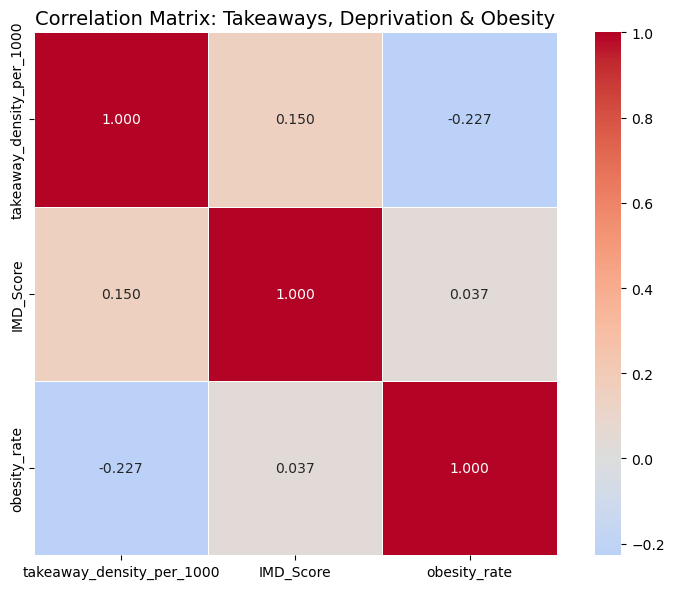


✅ Correlation matrix saved as 'correlation_matrix.png'

INTERPRETATION
⚠️ Takeaway density has a WEAK correlation with obesity rate.
   This does NOT strongly support Hypothesis 1


In [23]:
print("="*60)
print("CORRELATION MATRIX")
print("="*60)

# Select variables for correlation
corr_vars = ['takeaway_density_per_1000', 'IMD_Score', 'obesity_rate']
corr_matrix = final_data[corr_vars].corr()

print("Correlation Matrix:")
print(corr_matrix)

# Visualise the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Takeaways, Deprivation & Obesity', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

print("\n✅ Correlation matrix saved as 'correlation_matrix.png'")

# Simple interpretation
print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)

if corr_matrix.loc['takeaway_density_per_1000', 'obesity_rate'] > 0.3:
    print("✅ Takeaway density has a POSITIVE correlation with obesity rate.")
    print("   This supports Hypothesis 1: More takeaways = More obesity")
else:
    print("⚠️ Takeaway density has a WEAK correlation with obesity rate.")
    print("   This does NOT strongly support Hypothesis 1")

if corr_matrix.loc['IMD_Score', 'obesity_rate'] > 0.4:
    print("✅ Deprivation has a STRONG POSITIVE correlation with obesity rate.")
    print("   This supports that poverty is strongly linked to obesity")

if corr_matrix.loc['takeaway_density_per_1000', 'IMD_Score'] > 0.3:
    print("✅ Takeaway density is POSITIVELY correlated with deprivation.")
    print("   Poorer areas have more takeaways!")

## 4.4: Scatter Plots

Scatter plots help us see the relationship visually.
We'll create three plots:
1. Takeaway density vs Obesity rate
2. IMD Score vs Obesity rate
3. Takeaway density vs IMD Score

Each point is a London borough, labelled with its name.

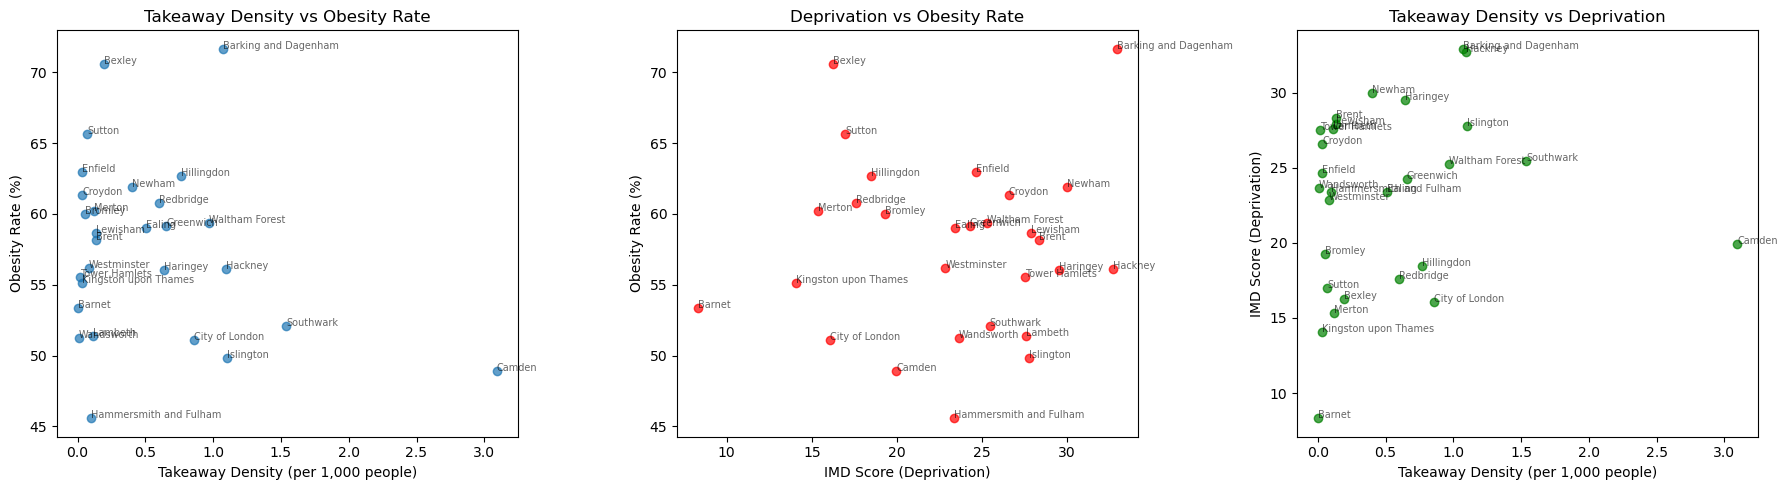

✅ Scatter plots saved as 'scatter_plots.png'


In [24]:

# Create three scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Takeaway density vs Obesity
ax = axes[0]
ax.scatter(final_data['takeaway_density_per_1000'], final_data['obesity_rate'], alpha=0.7)
ax.set_xlabel('Takeaway Density (per 1,000 people)')
ax.set_ylabel('Obesity Rate (%)')
ax.set_title('Takeaway Density vs Obesity Rate')

# Add labels for each borough
for i, row in final_data.iterrows():
    ax.annotate(row['BoroughName'], 
                (row['takeaway_density_per_1000'], row['obesity_rate']),
                fontsize=7, alpha=0.6)

# Plot 2: IMD Score vs Obesity
ax = axes[1]
ax.scatter(final_data['IMD_Score'], final_data['obesity_rate'], alpha=0.7, color='red')
ax.set_xlabel('IMD Score (Deprivation)')
ax.set_ylabel('Obesity Rate (%)')
ax.set_title('Deprivation vs Obesity Rate')

for i, row in final_data.iterrows():
    ax.annotate(row['BoroughName'], 
                (row['IMD_Score'], row['obesity_rate']),
                fontsize=7, alpha=0.6)

# Plot 3: Takeaway density vs IMD Score
ax = axes[2]
ax.scatter(final_data['takeaway_density_per_1000'], final_data['IMD_Score'], alpha=0.7, color='green')
ax.set_xlabel('Takeaway Density (per 1,000 people)')
ax.set_ylabel('IMD Score (Deprivation)')
ax.set_title('Takeaway Density vs Deprivation')

for i, row in final_data.iterrows():
    ax.annotate(row['BoroughName'], 
                (row['takeaway_density_per_1000'], row['IMD_Score']),
                fontsize=7, alpha=0.6)

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150)
plt.show()

print("✅ Scatter plots saved as 'scatter_plots.png'")

## 4.5: Which Boroughs Have the Most Takeaways?

Let's see which boroughs have the most takeaways and which have the least.
This helps us understand the distribution.

In [25]:

print("="*60)
print("TOP 5 BOROUGHS BY TAKEAWAY DENSITY")
print("="*60)
top_density = final_data.nlargest(5, 'takeaway_density_per_1000')
print(top_density[['BoroughName', 'takeaway_density_per_1000', 'IMD_Score', 'obesity_rate']])

print("\n" + "="*60)
print("BOTTOM 5 BOROUGHS BY TAKEAWAY DENSITY")
print("="*60)
bottom_density = final_data.nsmallest(5, 'takeaway_density_per_1000')
print(bottom_density[['BoroughName', 'takeaway_density_per_1000', 'IMD_Score', 'obesity_rate']])

print("\n" + "="*60)
print("TOP 5 BOROUGHS BY OBESITY RATE")
print("="*60)
top_obesity = final_data.nlargest(5, 'obesity_rate')
print(top_obesity[['BoroughName', 'obesity_rate', 'takeaway_density_per_1000', 'IMD_Score']])

print("\n" + "="*60)
print("BOTTOM 5 BOROUGHS BY OBESITY RATE")
print("="*60)
bottom_obesity = final_data.nsmallest(5, 'obesity_rate')
print(bottom_obesity[['BoroughName', 'obesity_rate', 'takeaway_density_per_1000', 'IMD_Score']])

TOP 5 BOROUGHS BY TAKEAWAY DENSITY
             BoroughName  takeaway_density_per_1000  IMD_Score  obesity_rate
6                 Camden                   3.092978  19.947173      48.90008
22             Southwark                   1.537552  25.437207      52.12476
15             Islington                   1.098536  27.750649      49.83933
11               Hackney                   1.090876  32.681488      56.09263
1   Barking and Dagenham                   1.074128  32.917840      71.65536

BOTTOM 5 BOROUGHS BY TAKEAWAY DENSITY
             BoroughName  takeaway_density_per_1000  IMD_Score  obesity_rate
2                 Barnet                   0.002469   8.319000      53.34249
26            Wandsworth                   0.008885  23.634000      51.26103
24         Tower Hamlets                   0.015065  27.542000      55.57481
16  Kingston upon Thames                   0.028953  14.048000      55.13740
9                Enfield                   0.033595  24.638455      62.97327

T

## 4.6: Visualising All Boroughs

Let's create a bar chart showing takeaway density for all 33 boroughs.
This helps us see the full picture at a glance.

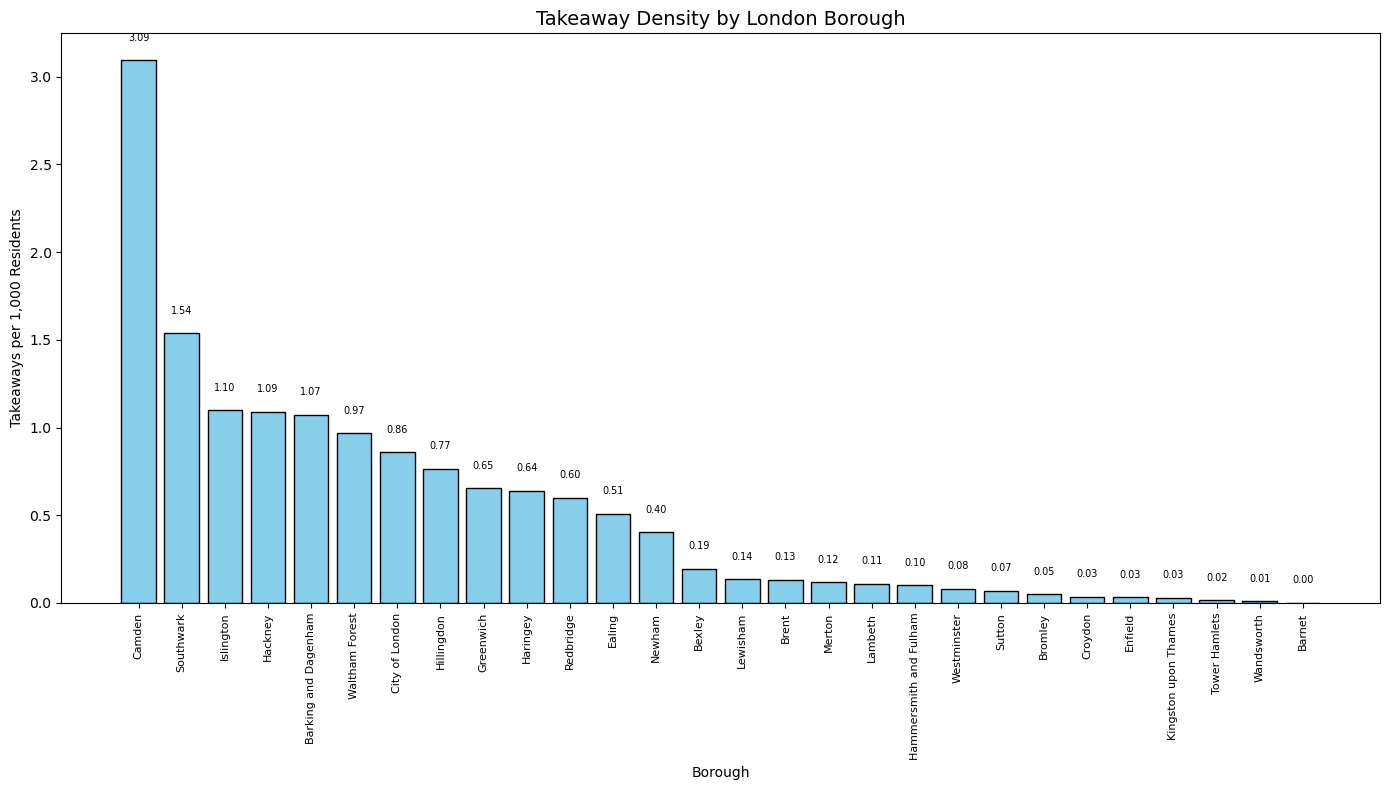

✅ Bar chart saved as 'borough_comparison.png'


In [26]:

# Sort by density
final_data_sorted = final_data.sort_values('takeaway_density_per_1000', ascending=False)

plt.figure(figsize=(14, 8))
bars = plt.bar(final_data_sorted['BoroughName'], 
              final_data_sorted['takeaway_density_per_1000'],
              color='skyblue', edgecolor='black')

plt.title('Takeaway Density by London Borough', fontsize=14)
plt.xlabel('Borough')
plt.ylabel('Takeaways per 1,000 Residents')
plt.xticks(rotation=90, fontsize=8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('borough_comparison.png', dpi=150)
plt.show()

print("✅ Bar chart saved as 'borough_comparison.png'")

## 4.7: Key Findings Summary

Let's summarise what we've learned from the data.

In [27]:

print("="*60)
print("KEY FINDINGS SUMMARY")
print("="*60)

# Calculate key metrics
avg_density = final_data['takeaway_density_per_1000'].mean()
avg_obesity = final_data['obesity_rate'].mean()
avg_imd = final_data['IMD_Score'].mean()

corr_density_obesity = final_data['takeaway_density_per_1000'].corr(final_data['obesity_rate'])
corr_imd_obesity = final_data['IMD_Score'].corr(final_data['obesity_rate'])

print(f"""
📊 Overall Statistics:
   - Average takeaway density: {avg_density:.2f} per 1,000 people
   - Average obesity rate: {avg_obesity:.2f}%
   - Average IMD Score: {avg_imd:.2f}

📈 Correlations:
   - Takeaway density vs Obesity: {corr_density_obesity:.3f}
   - Deprivation vs Obesity: {corr_imd_obesity:.3f}

🏆 Borough with highest takeaway density: {final_data.loc[final_data['takeaway_density_per_1000'].idxmax(), 'BoroughName']}
   ({final_data['takeaway_density_per_1000'].max():.2f} per 1,000)

🏆 Borough with lowest takeaway density: {final_data.loc[final_data['takeaway_density_per_1000'].idxmin(), 'BoroughName']}
   ({final_data['takeaway_density_per_1000'].min():.2f} per 1,000)

🏆 Borough with highest obesity rate: {final_data.loc[final_data['obesity_rate'].idxmax(), 'BoroughName']}
   ({final_data['obesity_rate'].max():.2f}%)

🏆 Borough with lowest obesity rate: {final_data.loc[final_data['obesity_rate'].idxmin(), 'BoroughName']}
   ({final_data['obesity_rate'].min():.2f}%)
""")

print("\n" + "="*60)
print("HYPOTHESIS CHECK")
print("="*60)

if corr_density_obesity > 0.3:
    print("✅ Hypothesis 1 (More takeaways = More obesity) is SUPPORTED")
    print(f"   Correlation: {corr_density_obesity:.3f}")
else:
    print("⚠️ Hypothesis 1 is WEAKLY supported or not supported")
    print(f"   Correlation: {corr_density_obesity:.3f}")

if corr_imd_obesity > 0.4:
    print("✅ Deprivation is strongly correlated with obesity")
    print(f"   Correlation: {corr_imd_obesity:.3f}")
    
    if corr_density_obesity < corr_imd_obesity:
        print("✅ Deprivation is a STRONGER predictor than takeaways")
        print("   This supports Hypothesis 2: Deprivation is the real driver")
    else:
        print("⚠️ Takeaways are still stronger than deprivation")
else:
    print("⚠️ Deprivation correlation is weaker than expected")

KEY FINDINGS SUMMARY

📊 Overall Statistics:
   - Average takeaway density: 0.51 per 1,000 people
   - Average obesity rate: 57.66%
   - Average IMD Score: 23.07

📈 Correlations:
   - Takeaway density vs Obesity: -0.227
   - Deprivation vs Obesity: 0.037

🏆 Borough with highest takeaway density: Camden
   (3.09 per 1,000)

🏆 Borough with lowest takeaway density: Barnet
   (0.00 per 1,000)

🏆 Borough with highest obesity rate: Barking and Dagenham
   (71.66%)

🏆 Borough with lowest obesity rate: Hammersmith and Fulham
   (45.58%)


HYPOTHESIS CHECK
⚠️ Hypothesis 1 is WEAKLY supported or not supported
   Correlation: -0.227
⚠️ Deprivation correlation is weaker than expected


##  4.8: Saving Results

Let's save the key findings for later use in the report.

In [28]:

# Save key statistics to a CSV
summary_stats = final_data.describe()
summary_stats.to_csv('final_data_summary.csv')

# Save correlation matrix
corr_matrix.to_csv('correlation_matrix.csv')

print("✅ Summary statistics saved as 'final_data_summary.csv'")
print("✅ Correlation matrix saved as 'correlation_matrix.csv'")

print("\n" + "="*60)
print("EDA COMPLETE!")
print("="*60)
print("\n📁 Files created:")
print("   - london_borough_final_data.csv (your dataset)")
print("   - final_data_summary.csv (summary statistics)")
print("   - correlation_matrix.csv (correlations)")
print("   - correlation_matrix.png (heatmap)")
print("   - scatter_plots.png (3 scatter plots)")
print("   - borough_comparison.png (bar chart)")

✅ Summary statistics saved as 'final_data_summary.csv'
✅ Correlation matrix saved as 'correlation_matrix.csv'

EDA COMPLETE!

📁 Files created:
   - london_borough_final_data.csv (your dataset)
   - final_data_summary.csv (summary statistics)
   - correlation_matrix.csv (correlations)
   - correlation_matrix.png (heatmap)
   - scatter_plots.png (3 scatter plots)
   - borough_comparison.png (bar chart)


In [29]:
# Load the summary statistics
summary = pd.read_csv('/Users/zisan/My Docs/Projects and Research(Git)/MSC Project/Advance-MSc-Project_Takeaway-Density-Deprivation-Obesity-in-London/final_data_summary.csv', index_col=0)

print("="*60)
print("FINAL DATA SUMMARY")
print("="*60)
print(summary)

FINAL DATA SUMMARY
       takeaway_count  IMD_Score     population  takeaway_density_per_1000  \
count       28.000000  28.000000      28.000000                  28.000000   
mean       131.714286  23.067836  282218.500000                   0.514800   
std        163.109792   6.041391   83888.144326                   0.668700   
min          1.000000   8.319000   15111.000000                   0.002469   
25%         14.750000  18.261333  221902.750000                   0.065116   
50%         44.000000  23.950304  300391.500000                   0.165540   
75%        208.250000  27.617137  332744.250000                   0.789220   
max        671.000000  32.917840  409342.000000                   3.092978   

       obesity_rate  
count     28.000000  
mean      57.662156  
std        6.130531  
min       45.580750  
25%       53.038058  
50%       58.395910  
75%       60.910655  
max       71.655360  


# Section 5: Trend Analysis Over Time
I will examine:

1.How the number of takeaways in London has changed over the years (from the FHRS data).

2.How the average obesity rate across London boroughs has changed over time (from the obesity data).

## 5.1 Takeaway count trends over time


5.1 Takeaway Count Trends in London Over Time
Takeaway counts per year (London):
Year
2002.0       1
2007.0       2
2008.0      15
2009.0      47
2010.0      65
2011.0      48
2012.0      35
2013.0      51
2014.0      63
2015.0      96
2016.0     213
2017.0     964
2018.0    2910
2019.0    5312
2020.0    3965
2021.0    6709
2022.0    1306
dtype: int64


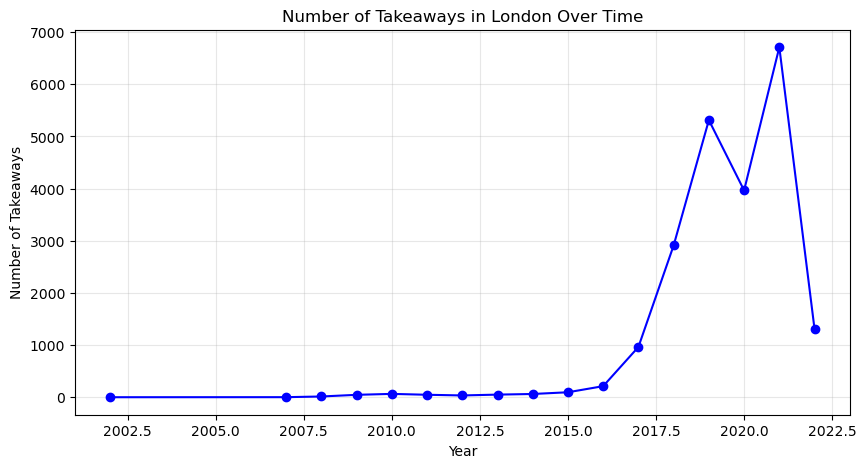

✅ Saved as 'takeaway_trend.png'

Linear regression of takeaways over time:
Slope (change per year): 260.89
R-squared: 0.4594
p-value: 0.0028
✅ The trend is statistically significant (p < 0.05).


In [34]:
print("\n5.1 Takeaway Count Trends in London Over Time")

# Check if RatingDate column exists and is datetime
if 'RatingDate' in fhrs_df.columns:
    # Ensure datetime
    fhrs_df['RatingDate'] = pd.to_datetime(fhrs_df['RatingDate'], errors='coerce')
    # Extract year
    fhrs_df['Year'] = fhrs_df['RatingDate'].dt.year
    
    # Filter for London boroughs (using LocalAuthorityName)
    # We have a list of London borough names from final_data
    london_boroughs = final_data['BoroughName'].unique()
    fhrs_london = fhrs_df[fhrs_df['LocalAuthorityName'].isin(london_boroughs)]
    
    # Count takeaways per year (only those with valid year)
    takeaways_by_year = fhrs_london.groupby('Year').size()
    # Drop NaN year
    takeaways_by_year = takeaways_by_year.dropna()
    
    print("Takeaway counts per year (London):")
    print(takeaways_by_year)
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(takeaways_by_year.index, takeaways_by_year.values, marker='o', linestyle='-', color='blue')
    plt.xlabel('Year')
    plt.ylabel('Number of Takeaways')
    plt.title('Number of Takeaways in London Over Time')
    plt.grid(True, alpha=0.3)
    plt.savefig('takeaway_trend.png', dpi=150)
    plt.show()
    print("✅ Saved as 'takeaway_trend.png'")
    
    # Statistical test: linear regression to see if trend is significant
    from scipy import stats
    years = takeaways_by_year.index.values
    counts = takeaways_by_year.values
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, counts)
    print(f"\nLinear regression of takeaways over time:")
    print(f"Slope (change per year): {slope:.2f}")
    print(f"R-squared: {r_value**2:.4f}")
    print(f"p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("✅ The trend is statistically significant (p < 0.05).")
    else:
        print("⚠️ The trend is not statistically significant (p >= 0.05).")
else:
    print("⚠️ RatingDate column not available, cannot analyze takeaway trends.")


## 5.2 Obesity rate trends over time


5.2 Obesity Rate Trends Over Time
Average obesity rate per year (London boroughs):
Year
2015    54.433268
2016    54.213710
2017    54.594050
2018    56.038001
2019    55.253636
2020    54.944533
2021    55.432331
2022    56.824166
2023    57.925068
2024    56.790783
Name: obesity_rate, dtype: float64


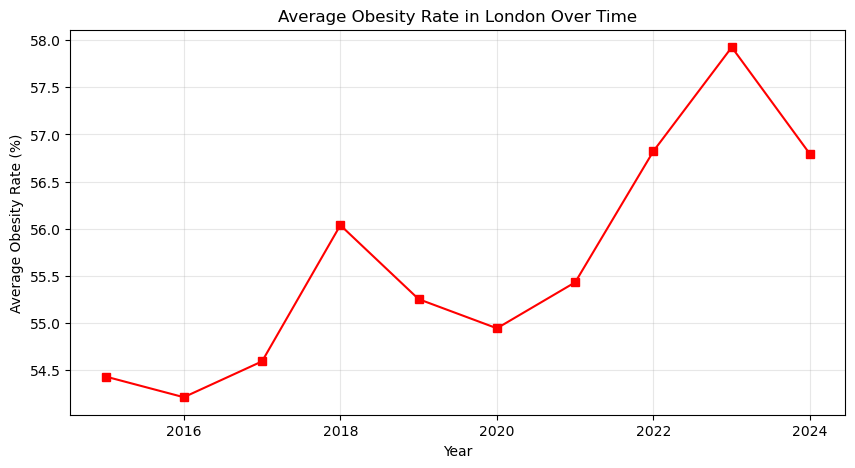

✅ Saved as 'obesity_trend.png'

Linear regression of obesity over time:
Slope (change per year): 0.3407
R-squared: 0.7166
p-value: 0.0020
✅ The trend is statistically significant (p < 0.05).


In [35]:
print("\n5.2 Obesity Rate Trends Over Time")

if 'Time period' in obesity_london.columns:
    # We have obesity_london from earlier (filtered for London boroughs)
    # Extract year (first part of 'Time period' e.g., '2015/16' -> 2015)
    obesity_london['Year'] = obesity_london['Time period'].str.split('/').str[0].astype(int)
    
    # Compute average obesity rate across London boroughs per year
    obesity_by_year = obesity_london.groupby('Year')['obesity_rate'].mean()
    print("Average obesity rate per year (London boroughs):")
    print(obesity_by_year)
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(obesity_by_year.index, obesity_by_year.values, marker='s', linestyle='-', color='red')
    plt.xlabel('Year')
    plt.ylabel('Average Obesity Rate (%)')
    plt.title('Average Obesity Rate in London Over Time')
    plt.grid(True, alpha=0.3)
    plt.savefig('obesity_trend.png', dpi=150)
    plt.show()
    print("✅ Saved as 'obesity_trend.png'")
    
    # Statistical test
    years = obesity_by_year.index.values
    rates = obesity_by_year.values
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, rates)
    print(f"\nLinear regression of obesity over time:")
    print(f"Slope (change per year): {slope:.4f}")
    print(f"R-squared: {r_value**2:.4f}")
    print(f"p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("✅ The trend is statistically significant (p < 0.05).")
    else:
        print("⚠️ The trend is not statistically significant (p >= 0.05).")
else:
    print("⚠️ Time period column not available, cannot analyze obesity trends.")

#### Interpretation of Trend Analysis
The trend analysis allows me to assess whether the time differences between datasets are likely to affect my conclusions. If both takeaways and obesity rates have been relatively stable, using data from different years is less of a concern. If there are significant changes, I must acknowledge the limitation and discuss how it could influence results.

In the final report, I will include these plots and the statistical test results to support my discussion of data limitations.